1 Setup libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

2 Get file path

In [ ]:

data_frame = pd.read_json(r"C:\Users\Admin\Documents\ML-cos3049\ML\data\data_labeled.json") #You Must use your data path not mine
data_frame.head()

3 Pick features

In [ ]:
feature_columns = [
        'Transaction amount', 'Account balance', 'Salary (per month)', 
        'Hour', 'DayOfWeek', 
        'Transaction Detail', 'Geological', 'Device Use', 'Location', 'Working Status'
    ]
features = data_frame[feature_columns]
target = data_frame['is_fraud']


4 Encode string to number

In [ ]:
text_columns = features.select_dtypes(include=['object']).columns
if len(text_columns) > 0:
    print(f"-> Đang mã hóa các cột: {list(text_columns)}")
    for column in text_columns:
        encoder = LabelEncoder()
        features[column] = encoder.fit_transform(features[column].astype(str))
        


5 Train model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
#80% train 20% test

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

6 Evaluate

In [ ]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, predictions, target_names=['Normal', 'Fraud']))
    

7 Show importances impact to Detection 

In [ ]:
feature_names = [
    'Transaction amount', 'Account balance', 'Salary (per month)', 
    'Hour', 'DayOfWeek', 'Transaction Detail', 
    'Geological', 'Device Use', 'Location', 'Working Status'
]

importance_df = pd.DataFrame({
    'Features': feature_names, 
    'Importances': model.feature_importances_
}).sort_values('Importances', ascending=False)

# Hiển thị kết quả
print(importance_df.head(5))


8 Visualization


8.1 Feature Importance Bar Chart (most important)
    Visualize top 5 importance

In [ ]:
import matplotlib.pyplot as plt

importance_df.sort_values('Importances').plot(kind='barh', x='Features', y='Importances', legend=False, color='teal')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance Score')

5.2 Confusion Matrix
    Shows true positives, false positives, etc. — critical for fraud detection where false negatives are costly.

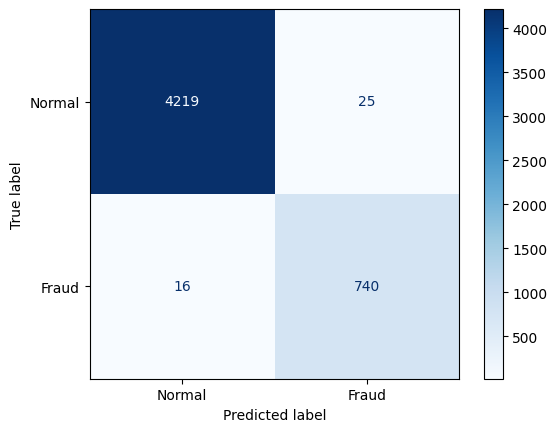

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['Normal','Fraud'], cmap='Blues')

3. ROC Curve
Visualizes the trade-off between catching fraud (recall) vs. false alarms (false positive rate).

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve - Random Forest')

4. Precision-Recall Curve
More informative than ROC for imbalanced datasets like fraud detection (few fraud vs many normal).

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
plt.title('Precision-Recall Curve')

5. Single Tree Visualization (optional/impressive)
Visualize one of the 100 trees to understand decision logic.

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0], feature_names=feature_columns, class_names=['Normal','Fraud'], max_depth=3, filled=True)